In [ ]:
pip install imbalanced-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("/content/ratings_Beauty.csv")

# data cleaning, encoding and handling null values

# UserId,ProductId,Rating,Timestamp
# A39HTATAQ9V7YF,0205616461,5.0,1369699200
# A3JM6GV9MNOF9X,0558925278,3.0,1355443200
# A1Z513UWSAAO0F,0558925278,5.0,1404691200
# A1WMRR494NWEWV,0733001998,4.0,1382572800
# A3IAAVS479H7M7,0737104473,1.0,1274227200


df.drop('Timestamp', axis = 1, inplace = True)

for col in df:
  if df[col].dtype == "object":
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


columns = ["ProductId", "Rating"]

imputer = SimpleImputer(strategy="most_frequent")
for col in columns:
  if col in df:
    if df[col].dtype!= "object" and df[col].isnull().sum() > 0:
      df.fillna(df[col].mean(), inplace=True)
    else:
      imputer.fit(df[[col]])
      df[col] = imputer.transform(df[[col]])

df.drop_duplicates(inplace = True)

df.dropna(inplace = True)

df['liked'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)
y = df['liked']

df.drop(['Rating', 'liked'], axis = 1, inplace = True)

smote = SMOTE()
x = df

x_resampled, y_resampled = smote.fit_resample(x, y)


x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size = 0.2, random_state = 42)

print(f"""

AFTER SMOTE


df.shape : {df.shape}
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")



AFTER SMOTE


df.shape : (2023070, 2)
x_train : (2490337, 2)
x_test : (622585, 2)
y_train : (2490337,)
y_test : (622585,)



In [3]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix )

xgb_model = XGBClassifier(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    eval_metric='logloss',
    objective='binary:logistic'
)

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred, average='weighted')
recall_scores = recall_score(y_test, y_pred, average='weighted')
f1_scores = f1_score(y_test, y_pred, average='weighted') # caluculate metrics considering class imbalance

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores} """)


Accuracy Score : 0.5279102451874041
Precision Score : 0.5279097944743729
Recall Score : 0.5279102451874041
F1 Score : 0.5279097112445201 


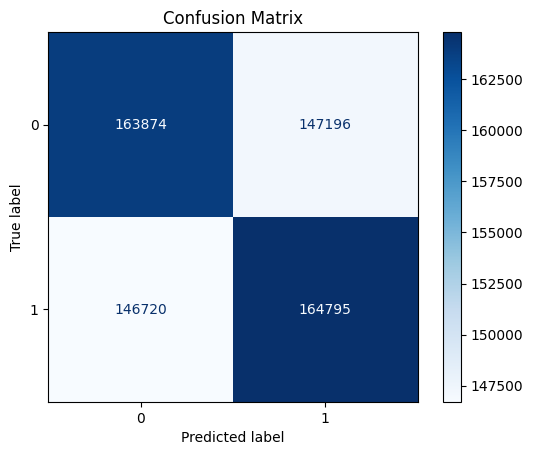

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # Assuming binary classification for 'liked'
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [7]:
import joblib
if joblib.dump(xgb_model, 'product_recommndation_system.pkl'):
  print("model saved")

model saved
